<a href="https://colab.research.google.com/github/2303A51876/GPU-Accelerated-Fraud-Detection-in-Banking-Transactions-HPC_PROJECT_T.SHYLASRI/blob/main/HPC-PROJECT-T.SHYLASRI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#T.Shylasri(2303A51876) - HPC PROJECT
# **TITLE - GPU-Accelerated Fraud Detection in Banking Transactions**

In [21]:
import torch
print(torch.cuda.is_available())

True


# **LOAD & CHECK DATASET**

In [22]:
import pandas as pd

# Load dataset
df = pd.read_csv('/content/creditcard_2023.csv')

# Basic info
print("Shape:", df.shape)
print(df.info())

# Check fraud distribution
print(df['Class'].value_counts())

df.head()

Shape: (568630, 31)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 568630 entries, 0 to 568629
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   id      568630 non-null  int64  
 1   V1      568630 non-null  float64
 2   V2      568630 non-null  float64
 3   V3      568630 non-null  float64
 4   V4      568630 non-null  float64
 5   V5      568630 non-null  float64
 6   V6      568630 non-null  float64
 7   V7      568630 non-null  float64
 8   V8      568630 non-null  float64
 9   V9      568630 non-null  float64
 10  V10     568630 non-null  float64
 11  V11     568630 non-null  float64
 12  V12     568630 non-null  float64
 13  V13     568630 non-null  float64
 14  V14     568630 non-null  float64
 15  V15     568630 non-null  float64
 16  V16     568630 non-null  float64
 17  V17     568630 non-null  float64
 18  V18     568630 non-null  float64
 19  V19     568630 non-null  float64
 20  V20     568630 non-null  flo

,id,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-0.260648,-0.469648,2.496266,-0.083724,0.129681,0.732898,0.519014,-0.130006,0.727159,...,-0.110552,0.217606,-0.134794,0.165959,0.126280,-0.434824,-0.081230,-0.151045,17982.10,0
1,1,0.985100,-0.356045,0.558056,-0.429654,0.277140,0.428605,0.406466,-0.133118,0.347452,...,-0.194936,-0.605761,0.079469,-0.577395,0.190090,0.296503,-0.248052,-0.064512,6531.37,0
2,2,-0.260272,-0.949385,1.728538,-0.457986,0.074062,1.419481,0.743511,-0.095576,-0.261297,...,-0.005020,0.702906,0.945045,-1.154666,-0.605564,-0.312895,-0.300258,-0.244718,2513.54,0
3,3,-0.152152,-0.508959,1.746840,-1.090178,0.249486,1.143312,0.518269,-0.065130,-0.205698,...,-0.146927,-0.038212,-0.214048,-1.893131,1.003963,-0.515950,-0.165316,0.048424,5384.44,0
4,4,-0.206820,-0.165280,1.527053,-0.448293,0.106125,0.530549,0.658849,-0.212660,1.049921,...,-0.106984,0.729727,-0.161666,0.312561,-0.414116,1.071126,0.023712,0.419117,14278.97,0


# **DATA CLEANING**

In [23]:
# Remove missing values
df = df.dropna()

# Reduce size for faster execution (important)
df = df.head(50000)

print("After cleaning:", df.shape)

After cleaning: (50000, 31)


# **PREPARE DATA (CPU)**

In [24]:
# Features & Target
X = df.drop(['id','Class'], axis=1)
y = df['Class']

# **TRAIN-TEST-SPLIT (CPU)**

In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# **TRAIN CPU MODEL**

In [26]:
from sklearn.ensemble import RandomForestClassifier
import time

start = time.time()

cpu_model = RandomForestClassifier()
cpu_model.fit(X_train, y_train)

end = time.time()

cpu_time = end - start
print("CPU Time:", cpu_time)

CPU Time: 21.98085117340088


# **CPU EVALUATION**

In [27]:
from sklearn.metrics import classification_report

y_pred_cpu = cpu_model.predict(X_test)

print(classification_report(y_test, y_pred_cpu))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      9966
           1       0.97      0.91      0.94        34

    accuracy                           1.00     10000
   macro avg       0.98      0.96      0.97     10000
weighted avg       1.00      1.00      1.00     10000



# **ENABLE GPU & INSTALL LIBRARIES**

In [28]:
!pip install cudf-cu11 --extra-index-url=https://pypi.nvidia.com
!pip install cuml-cu11 --extra-index-url=https://pypi.nvidia.com

Looking in indexes: https://pypi.org/simple, https://pypi.nvidia.com
Looking in indexes: https://pypi.org/simple, https://pypi.nvidia.com


# **GPU USING PYTORCH**

In [29]:
import torch
import time
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load dataset
df = pd.read_csv('/content/creditcard_2023.csv')

# Clean
df = df.dropna()
df = df.head(50000)

# Features & Target
X = df.drop(['id','Class'], axis=1)
y = df['Class']

# Scale data (important for GPU)
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Convert to tensors
X_train = torch.tensor(X_train, dtype=torch.float32).cuda()
y_train = torch.tensor(y_train.values, dtype=torch.float32).cuda()

# Simple model
model = torch.nn.Sequential(
    torch.nn.Linear(X_train.shape[1], 64),
    torch.nn.ReLU(),
    torch.nn.Linear(64, 1),
    torch.nn.Sigmoid()
).cuda()

criterion = torch.nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

# Training
start = time.time()

for epoch in range(5):  # small epochs for speed
    optimizer.zero_grad()
    outputs = model(X_train).squeeze()
    loss = criterion(outputs, y_train)
    loss.backward()
    optimizer.step()

end = time.time()

gpu_time = end - start
print("GPU Time (PyTorch):", gpu_time)

GPU Time (PyTorch): 0.013515710830688477


# **COMPARISON CPU vs GPU TIME**

In [30]:
print("CPU Time:", cpu_time)
print("GPU Time:", gpu_time)

CPU Time: 21.98085117340088
GPU Time: 0.013515710830688477


# **VISUALIZATION (GRAPH)**

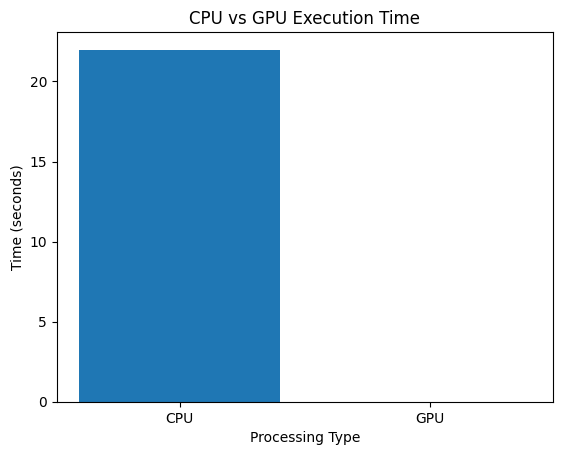

In [31]:
import matplotlib.pyplot as plt

labels = ['CPU', 'GPU']
times = [cpu_time, gpu_time]

plt.bar(labels, times)
plt.title("CPU vs GPU Execution Time")
plt.xlabel("Processing Type")
plt.ylabel("Time (seconds)")
plt.show()

# **CONFUSION MATRIX (CPU MODEL)**

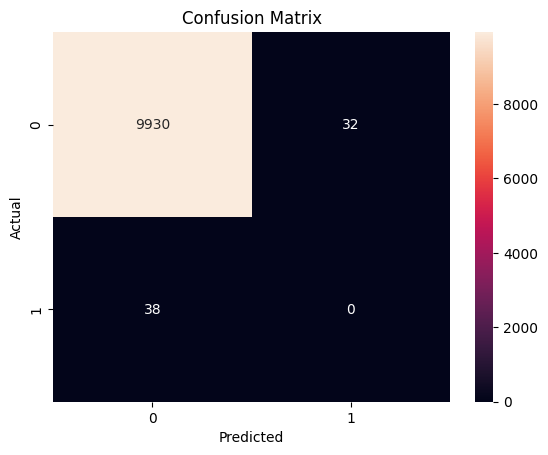

In [32]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred_cpu)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# **ROC CURVE (CPU MODEL)**

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


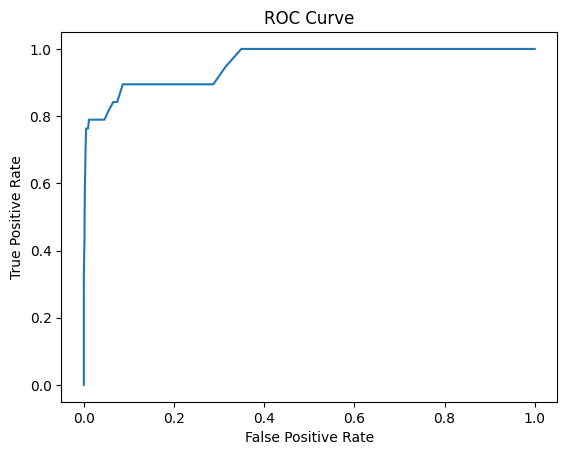

In [33]:
from sklearn.metrics import roc_curve

y_prob = cpu_model.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr)
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()